# Snowpack Ballistic Deposition Model
## Imports and Dependencies
(Expected total code runtime: 1-2 minutes)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from numpy import array, arange, mean, std, sqrt, zeros
from numpy.random import default_rng
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress

from module_libraries.my_stats import half_frame, my_fontsize

print('Done.')

Done.


## Main Functions

In [2]:
def ballistic_deposition(L, T, sigma=0.0, storm_size=None, rng=None,
                          measure_every=None):
    """
    Simulate ballistic deposition on a 1D surface of width L for T timesteps.

    Inputs:
    L     : int - system width (number of columns)
    T     : int - total number of deposition events
    sigma : float - Gaussian kernel width for spatial correlation.
    storm_size   : int - record cumulative height snapshots every storm_size steps for layer analysis.
    rng          : numpy Generator for reproducibility.
    measure_every: int - compute W(t) only every this many steps.
                            Defaults to max(1, T//500) so at most 500
                            points are recorded regardless of T.
    Returns:
    h          : array (L,) - final height profile
    t_measured : array (n_points,) - timesteps at which W was recorded
    W_measured : array (n_points,) - surface width at those timesteps
    snapshots  : list of arrays - height profiles at storm boundaries
    """
    if rng is None:
        rng = default_rng()
    if measure_every is None:
        measure_every = max(1, T // 500)
    h         = zeros(L, dtype=np.int64)
    snapshots = []
    t_list    = []
    W_list    = []

    # Pre-generate all column choices upfront for sigma=0 for time
    if sigma <= 0.0:
        all_cols = rng.integers(0, L, size=T)
    else:
        all_cols = None

    for t in range(T):
        if sigma <= 0.0:
            col = all_cols[t]
        else:
            raw     = rng.standard_normal(L)
            weights = gaussian_filter1d(raw, sigma=sigma, mode='wrap')
            weights -= weights.min()
            weights += 1e-8
            weights /= weights.sum()
            col = rng.choice(L, p=weights)

        left  = (col - 1) % L
        right = (col + 1) % L
        h[col] = max(h[col], h[left], h[right]) + 1

        #Measure W only every measure_every step
        if (t + 1) % measure_every == 0:
            t_list.append(t + 1)
            W_list.append(sqrt(mean(h**2) - mean(h)**2))
        if storm_size is not None and (t + 1) % storm_size == 0: # Record snapshot at boundary
            snapshots.append(h.copy())

    return h, array(t_list), array(W_list), snapshots


def ballistic_deposition_variable_storms(L, n_storms, mean_storm_size,
                                          sigma_storm=0.8, sigma=0.0, rng=None):
    """
    Simulate ballistic deposition where each storm deposits a changing number
    of particles drawn from a log-normal distribution.

    A log-normal distribution is the standard model for precipitation accumulation, 
    producing many small-moderate storms and a long right tail of rare large events, 
    consistent with observed snowfall records.

    Parameters:
    L               : int - system width
    n_storms        : int - number of storm events
    mean_storm_size : int - median storm size. (not mean)
    sigma_storm     : float - log-normal shape parameter controlling skewness
    sigma           : float - spatial correlation length
    rng             : numpy Generator
    Returns:
    h           : array (L,) - final height profile
    snapshots   : list of arrays - cumulative height profiles after each storm
    storm_sizes : array (n_storms) - actual size of each storm drawn
    """
    if rng is None:
        rng = default_rng()

    h           = zeros(L, dtype=np.int64)
    snapshots   = []
    storm_sizes = []

    for storm in range(n_storms):
        # np.log(mean_storm_size) sets the median to mean_storm_size
        size = int(max(1, round(rng.lognormal(mean=np.log(mean_storm_size),
                                               sigma=sigma_storm))))
        storm_sizes.append(size)

        if sigma <= 0.0:
            all_cols = rng.integers(0, L, size=size)

        for t in range(size):
            if sigma <= 0.0:
                col = all_cols[t]
            else:
                raw     = rng.standard_normal(L)
                weights = gaussian_filter1d(raw, sigma=sigma, mode='wrap')
                weights -= weights.min()
                weights += 1e-8
                weights /= weights.sum()
                col = rng.choice(L, p=weights)

            left  = (col - 1) % L
            right = (col + 1) % L
            h[col] = max(h[col], h[left], h[right]) + 1
        snapshots.append(h.copy())

    return h, snapshots, array(storm_sizes)
print('Done.')

Done.


In [3]:
def extract_beta(t_measured, W_measured, t_end_frac=0.02):
    """
    Extract growth exponent beta from early-time power-law.
    
    Parameters:
    t_measured : array - timesteps at which W was recorded
    W_measured : array - surface width values
    t_end_frac : float - fit only up to this fraction of total time

    Returns:
    slope     : float - estimated beta
    intercept : float - log-space intercept
    """
    T_total  = t_measured[-1]
    t_cutoff = t_end_frac * T_total

    mask = (W_measured > 0) & (t_measured <= t_cutoff)
    if mask.sum() < 3:
        return float('nan'), float('nan')
    slope, intercept, r, p, se = linregress(np.log(t_measured[mask]),
                                             np.log(W_measured[mask]))
    return slope, intercept

def extract_alpha(L_values, W_sat_values):
    """
    Extract roughness exponent alpha from Wsat ~ L^alpha.
    """
    slope, intercept, r, p, se = linregress(np.log(array(L_values)),
                                             np.log(array(W_sat_values)))
    return slope, intercept
print('Done.')

Done.


## Layer Statistics

In [4]:
def compute_layer_statistics(snapshots):
    """
    Compute per-layer structural statistics from cumulative height snapshots.

    Each snapshot represents the cumulative height profile at the end of one
    storm event. The layer deposited by storm k is the difference between
    snapshot k and snapshot k-1.

    Parameters:
    snapshots - list of 1D arrays, the cumulative height profiles at storm boundaries
    Returns:
    intra_var   : array (n_storms,) - spatial variance of thickness within each layer
    inter_delta : array (n_storms-1,) - mean absolute thickness difference between adjacent layers
    xi_values   : array (n_storms,) - lateral coherence length per layer (lattice units), estimated as the lag 
                                            at which the spatial autocorrelation drops below 1/e.
    """
    n_storms  = len(snapshots)
    intra_var   = zeros(n_storms)
    inter_delta = zeros(n_storms - 1)
    xi_values   = zeros(n_storms)

    for k in range(n_storms): # Thickness of layer k
        if k == 0:
            layer_profile = snapshots[0].astype(float)
        else:
            layer_profile = (snapshots[k] - snapshots[k - 1]).astype(float)

        intra_var[k] = np.var(layer_profile)
        profile_centered = layer_profile - mean(layer_profile)
        if std(layer_profile) > 0:
            autocorr  = np.correlate(profile_centered, profile_centered, mode='full')
            autocorr  = autocorr[len(autocorr) // 2:]   # non-negative lags only
            autocorr /= autocorr[0]                      # normalize to 1 at lag 0
            below = np.where(autocorr < np.exp(-1))[0]
            xi_values[k] = below[0] if len(below) > 0 else len(autocorr)
        else:
            xi_values[k] = 0.0

    for k in range(n_storms - 1):
        layer_k  = (snapshots[k]     - (snapshots[k - 1] if k > 0 else 0)).astype(float)
        layer_k1 = (snapshots[k + 1] -  snapshots[k]).astype(float)
        inter_delta[k] = mean(np.abs(layer_k1 - layer_k))

    return intra_var, inter_delta, xi_values
print('Done.')

Done.


## Code Validation

In [5]:
L_values     = [32, 64, 128, 256]
T_factor     = 20
n_replicates = 5
rng_seed     = 123

print('KPZ Validation - sigma = 0 (uncorrelated baseline)')
print(f'System sizes L: {L_values}')
print(f'T = {T_factor} * L^2  |  Replicates per L: {n_replicates}')
print()

W_sat_means    = []
beta_estimates = []
W_avg_store    = {}

for L in L_values:
    T = T_factor * L * L
    W_reps = []
    t_ref  = None

    for rep in range(n_replicates):
        rng = default_rng(rng_seed + rep * 1000 + L)
        _, t_meas, W_meas, _ = ballistic_deposition(L, T, sigma=0.0, rng=rng)
        W_reps.append(W_meas)
        if t_ref is None:
            t_ref = t_meas

    W_avg = mean(array(W_reps), axis=0)
    W_avg_store[L] = (t_ref, W_avg)

    sat_start = int(0.8 * len(W_avg))
    W_sat_means.append(mean(W_avg[sat_start:]))

    beta, _ = extract_beta(t_ref, W_avg)
    beta_estimates.append(beta)

    print(f'  L={L:4d} | T={T:9d} | W_sat={W_sat_means[-1]:.3f} | beta={beta:.3f}')

W_sat_means = array(W_sat_means)
alpha, alpha_intercept = extract_alpha(array(L_values), W_sat_means)

print()
print(f'Roughness exponent alpha = {alpha:.3f} (KPZ theory: 0.500)')
print(f'Mean growth exponent beta  = {mean(beta_estimates):.3f} (KPZ theory: 0.333)')

KPZ Validation - sigma = 0 (uncorrelated baseline)
System sizes L: [32, 64, 128, 256]
T = 20 * L^2  |  Replicates per L: 5

  L=  32 | T=    20480 | W_sat=5.932 | beta=0.351
  L=  64 | T=    81920 | W_sat=7.986 | beta=0.312
  L= 128 | T=   327680 | W_sat=9.652 | beta=0.243
  L= 256 | T=  1310720 | W_sat=13.366 | beta=0.303

Roughness exponent alpha = 0.379 (KPZ theory: 0.500)
Mean growth exponent beta  = 0.302 (KPZ theory: 0.333)


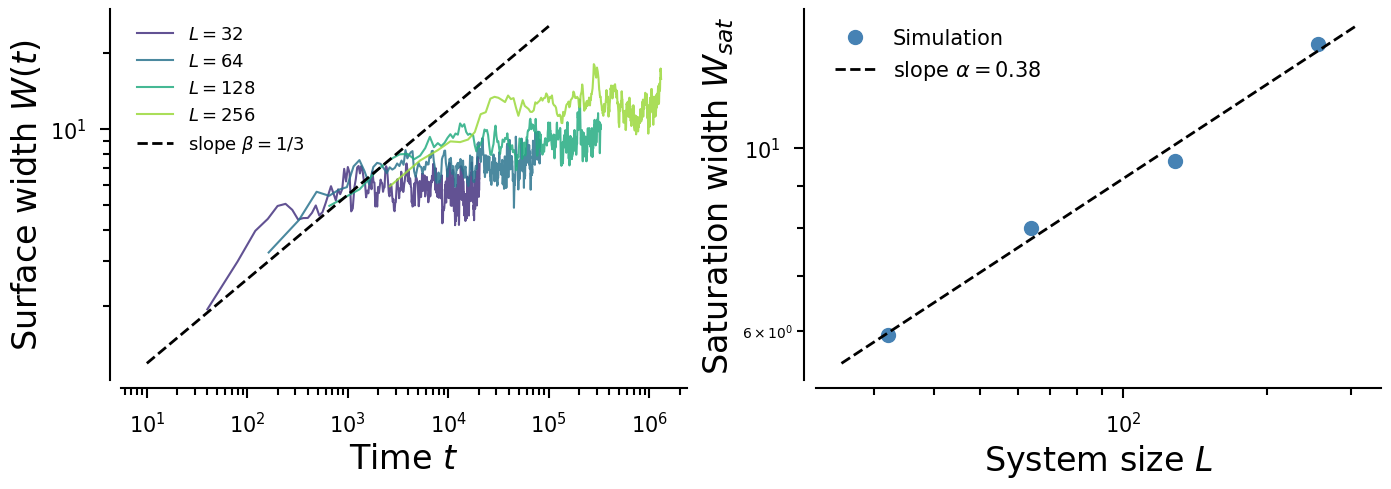

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = cm.viridis(np.linspace(0.15, 0.85, len(L_values)))

#W(t)
ax = axes[0]
half_frame(ax, 'Time $t$', 'Surface width $W(t)$', font_size=my_fontsize)
for idx, L in enumerate(L_values):
    t_ref, W_avg = W_avg_store[L]
    ax.loglog(t_ref, W_avg, '-', color=colors[idx],
              alpha=0.85, lw=1.5, label=f'$L={L}$')
t_ref_line = arange(10, 100000)
ax.loglog(t_ref_line, 0.55 * t_ref_line**(1/3), 'k--', lw=2,
          label=r'slope $\beta=1/3$')
ax.legend(loc='upper left', frameon=False, fontsize=my_fontsize - 2)

# Wsat vs L
ax = axes[1]
half_frame(ax, 'System size $L$', 'Saturation width $W_{sat}$', font_size=my_fontsize)
ax.loglog(L_values, W_sat_means, 'o', color='steelblue', markersize=10,
          label='Simulation')
L_fit = np.linspace(L_values[0] * 0.8, L_values[-1] * 1.2, 100)
ax.loglog(L_fit, np.exp(alpha_intercept) * L_fit**alpha, 'k--', lw=2,
          label=fr'slope $\alpha={alpha:.2f}$')
ax.legend(loc='upper left', frameon=False, fontsize=my_fontsize)

plt.tight_layout()
plt.show()

## Layer Statistics Implementation

In [7]:
L_layer     = 256
n_storms    = 40
storm_size  = L_layer
T_layer     = n_storms * storm_size
sigma_cases = [0, 8, 32]
n_rep_layer = 8
print(f'Layer analysis | L={L_layer}, {n_storms} storms x {storm_size} particles, '
      f'replicates={n_rep_layer}')
print()
layer_results = {}

for sigma in sigma_cases:
    all_intra = []
    all_inter = []
    all_xi    = []

    for rep in range(n_rep_layer):
        rng = default_rng(rng_seed + rep * 500 + int(sigma))
        _, _, _, snaps = ballistic_deposition(L_layer, T_layer,
                                               sigma=float(sigma),
                                               storm_size=storm_size,
                                               rng=rng)
        intra, inter, xi = compute_layer_statistics(snaps)
        all_intra.append(intra)
        all_inter.append(inter)
        all_xi.append(xi)

    layer_results[sigma] = {
        'intra_mean' : mean(array(all_intra), axis=0),
        'intra_std'  : std(array(all_intra),  axis=0),
        'inter_mean' : mean(array(all_inter), axis=0),
        'inter_std'  : std(array(all_inter),  axis=0),
        'xi_mean'    : mean(array(all_xi),    axis=0),
        'xi_std'     : std(array(all_xi),     axis=0),
    }
    print(f'  sigma={sigma:2d} | '
          f'mean intra-var = {mean(layer_results[sigma]["intra_mean"]):.4f} | '
          f'mean inter-delta = {mean(layer_results[sigma]["inter_mean"]):.4f} | '
          f'mean xi = {mean(layer_results[sigma]["xi_mean"]):.2f}')

Layer analysis | L=256, 40 storms x 256 particles, replicates=8

  sigma= 0 | mean intra-var = 22.9024 | mean inter-delta = 5.3200 | mean xi = 1.01
  sigma= 8 | mean intra-var = 22.7299 | mean inter-delta = 5.3237 | mean xi = 1.01
  sigma=32 | mean intra-var = 22.5810 | mean inter-delta = 5.3024 | mean xi = 1.00


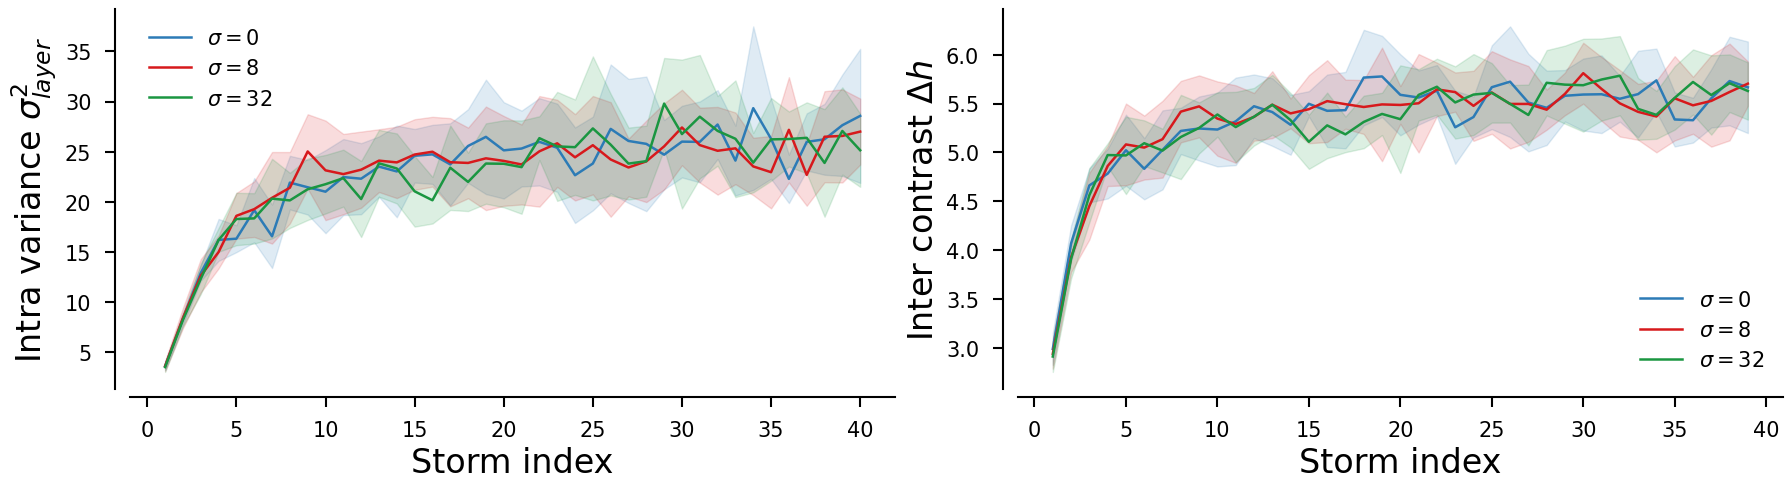

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
case_colors = {0: '#2c7bb6', 8: '#d7191c', 32: '#1a9641'}
storm_axis  = arange(1, n_storms + 1)

# Intra variance
ax = axes[0]
half_frame(ax, 'Storm index', r'Intra variance $\sigma^2_{layer}$',
           font_size=my_fontsize)
for sigma in sigma_cases:
    r = layer_results[sigma]
    c = case_colors[sigma]
    ax.plot(storm_axis, r['intra_mean'], '-', color=c, lw=1.8, label=fr'$\sigma={sigma}$')
    ax.fill_between(storm_axis,
                    r['intra_mean'] - r['intra_std'],
                    r['intra_mean'] + r['intra_std'],
                    color=c, alpha=0.15)
ax.legend(frameon=False, fontsize=my_fontsize)

# Inter Contrast
ax = axes[1]
half_frame(ax, 'Storm index', r'Inter contrast $\Delta h$',
           font_size=my_fontsize)
for sigma in sigma_cases:
    r = layer_results[sigma]
    c = case_colors[sigma]
    ax.plot(arange(1, n_storms), r['inter_mean'], '-', color=c, lw=1.8,
            label=fr'$\sigma={sigma}$')
    ax.fill_between(arange(1, n_storms),
                    r['inter_mean'] - r['inter_std'],
                    r['inter_mean'] + r['inter_std'],
                    color=c, alpha=0.15)
ax.legend(frameon=False, fontsize=my_fontsize)

plt.tight_layout()
plt.show()

## Visualization of Weak-Layer Propogation
Weaker layers more prone to triggering an avalanche are shaded darker reds,
stronger layers remain lighter yellows.

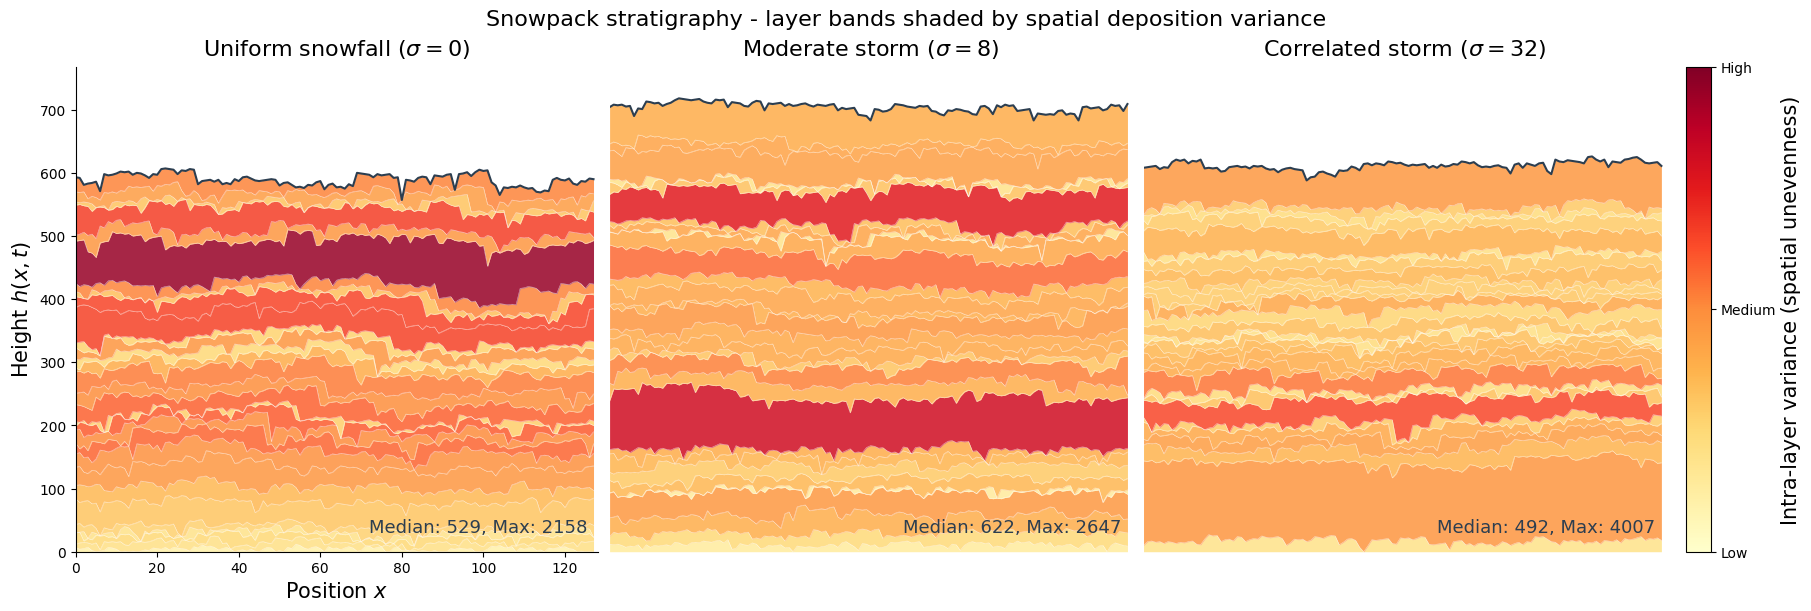

Storm size distribution: median=492, max=4007, min=125


In [9]:
L_vis           = 128
mean_storm_size = 500
std_storm_size  = 300
n_storms_vis    = 30
sigma_vis       = [0, 8, 32]
titles = {0:  r'Uniform snowfall ($\sigma=0$)',
          8:  r'Moderate storm ($\sigma=8$)',
          32: r'Correlated storm ($\sigma=32$)'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True,
                          constrained_layout=True)
x_axis = arange(L_vis)
all_vars = []
all_snaps_store = {}

for sigma in sigma_vis:
    rng = default_rng(rng_seed + int(sigma))
    _, snaps, storm_sizes = ballistic_deposition_variable_storms(
                                L_vis, n_storms_vis,
                                mean_storm_size, sigma_storm=0.8,
                                sigma=float(sigma), rng=rng)
    all_snaps_store[sigma] = (snaps, storm_sizes)
    n_actual     = len(snaps)
    layer_matrix = zeros((n_actual, L_vis))
    for k in range(n_actual):
        if k == 0:
            layer_matrix[k] = snaps[0].astype(float)
        else:
            layer_matrix[k] = (snaps[k] - snaps[k-1]).astype(float)

    for k in range(n_actual):
        all_vars.append(np.var(layer_matrix[k]))

g_min = min(all_vars)
g_max = max(all_vars)

for ax_idx, sigma in enumerate(sigma_vis):
    ax = axes[ax_idx]
    snaps, storm_sizes = all_snaps_store[sigma]

    n_actual     = len(snaps)
    layer_matrix = zeros((n_actual, L_vis))
    for k in range(n_actual):
        if k == 0:
            layer_matrix[k] = snaps[0].astype(float)
        else:
            layer_matrix[k] = (snaps[k] - snaps[k-1]).astype(float)

    layer_vars = array([np.var(layer_matrix[k]) for k in range(n_actual)])

    for k in range(n_actual): # Shade each layer band by its variance
        c_intensity = (layer_vars[k] - g_min) / (g_max - g_min) if g_max > g_min else 0.5
        fill_color  = cm.YlOrRd(0.1 + 0.85 * c_intensity)
        bottom = snaps[k-1].astype(float) if k > 0 else zeros(L_vis)
        top    = snaps[k].astype(float)

        ax.fill_between(x_axis, bottom, top,
                        color=fill_color, alpha=0.85, linewidth=0)

    for k in range(n_actual): # Draw storm boundary lines
        ax.plot(x_axis, snaps[k], '-', color='white', lw=0.4, alpha=0.6)
    ax.plot(x_axis, snaps[-1], '-', color='#2c3e50', lw=1.5)
    ax.text(0.98, 0.04,
            f'Median: {np.median(storm_sizes):.0f}, Max: {max(storm_sizes):.0f}',
            transform=ax.transAxes, ha='right', fontsize=my_fontsize - 2,
            color='#2c3e50')

    ax.set_xlim(0, L_vis)
    ax.set_title(titles[sigma], fontsize=my_fontsize + 1, pad=8)
    ax.set_xlabel('Position $x$', fontsize=my_fontsize)

    if ax_idx == 0:
        ax.set_ylabel('Height $h(x,t)$', fontsize=my_fontsize)
        ax.yaxis.set_ticks_position('left')
        ax.xaxis.set_ticks_position('bottom')
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
    else:
        ax.set_axis_off()

max_height = max(all_snaps_store[s][0][-1].max() for s in sigma_vis)
axes[0].set_ylim(0, max_height + 50) #increase y-axis by 50 for asthetic

sm = plt.cm.ScalarMappable(cmap='YlOrRd',
                            norm=plt.Normalize(vmin=g_min, vmax=g_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[2], fraction=0.08, pad=0.04)
cbar.set_label('Intra-layer variance (spatial unevenness)', fontsize=my_fontsize)
cbar.set_ticks([g_min, (g_min + g_max) / 2, g_max])
cbar.set_ticklabels(['Low', 'Medium', 'High'])

fig.suptitle('Snowpack stratigraphy - layer bands shaded by spatial deposition variance',
             fontsize=my_fontsize + 1)
plt.show()

print(f'Storm size distribution: median={np.median(storm_sizes):.0f}, '
      f'max={max(storm_sizes)}, min={min(storm_sizes)}')

## Plotting Summary Statistics from Visualization

In [10]:
sigma_all   = [0, 2, 4, 8, 16, 32]
n_rep_agg   = 8
agg_intra = []
agg_inter = []
agg_xi = []
agg_wli = []
agg_wli_std = []
print('Aggregate summary across all sigma values:')
print()

for sigma in sigma_all:
    rep_intra = []
    rep_inter = []
    rep_xi = []
    rep_wli = []

    for rep in range(n_rep_agg):
        rng = default_rng(rng_seed + rep * 300 + int(sigma))
        _, _, _, snaps = ballistic_deposition(L_layer, T_layer,
                                              sigma=float(sigma),
                                              storm_size=storm_size,
                                              rng=rng)
        intra, inter, xi = compute_layer_statistics(snaps)

        m_intra_rep = mean(intra)
        m_inter_rep = mean(inter)
        rep_intra.append(m_intra_rep)
        rep_inter.append(m_inter_rep)
        rep_xi.append(mean(xi))
        
        wli_rep = m_inter_rep / sqrt(m_intra_rep) if m_intra_rep > 0 else 0.0
        rep_wli.append(wli_rep)

    agg_intra.append(mean(rep_intra))
    agg_inter.append(mean(rep_inter))
    agg_xi.append(mean(rep_xi))
    agg_wli.append(mean(rep_wli))
    agg_wli_std.append(std(rep_wli))

    print(f'  sigma={sigma:4.1f} | intra={mean(rep_intra):.4f} | '
          f'inter={mean(rep_inter):.4f} | xi={mean(rep_xi):.2f} | '
          f'WLI={mean(rep_wli):.4f} +/- {std(rep_wli):.4f}')

Aggregate summary across all sigma values:

  sigma= 0.0 | intra=22.9483 | inter=5.3549 | xi=1.01 | WLI=1.1181 +/- 0.0125
  sigma= 2.0 | intra=22.3647 | inter=5.2988 | xi=1.01 | WLI=1.1210 +/- 0.0136
  sigma= 4.0 | intra=23.2629 | inter=5.3714 | xi=1.01 | WLI=1.1138 +/- 0.0059
  sigma= 8.0 | intra=22.9272 | inter=5.3432 | xi=1.01 | WLI=1.1163 +/- 0.0084
  sigma=16.0 | intra=22.3812 | inter=5.3058 | xi=1.02 | WLI=1.1221 +/- 0.0109
  sigma=32.0 | intra=23.1255 | inter=5.3501 | xi=1.01 | WLI=1.1131 +/- 0.0113


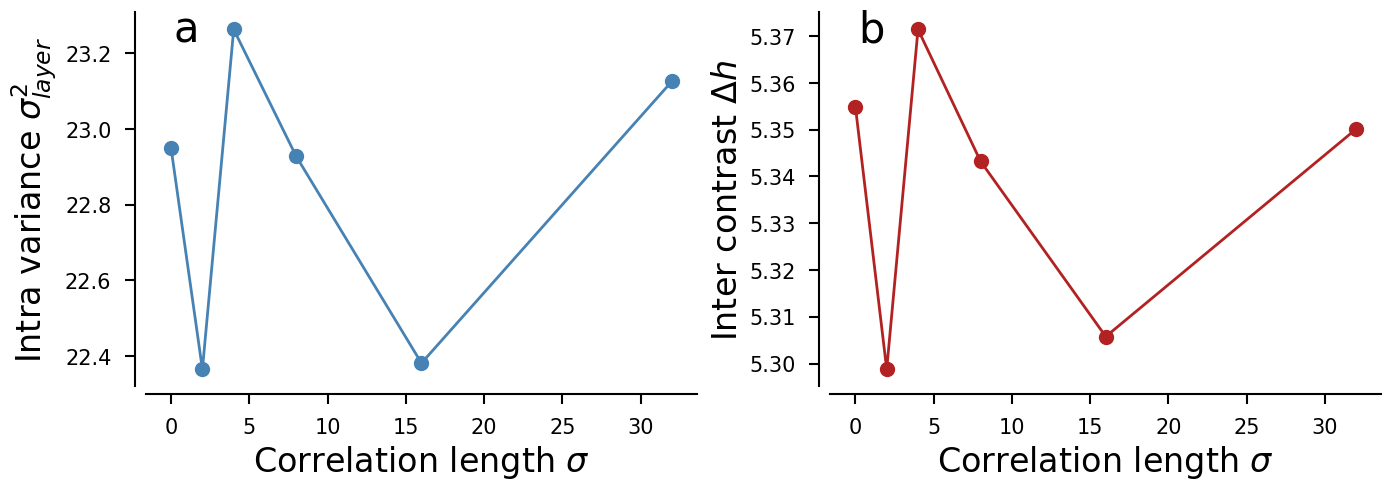

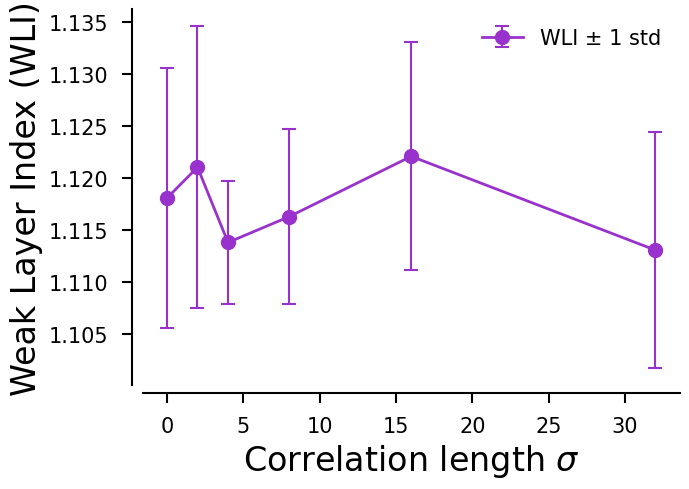

In [11]:
sigma_arr = array(sigma_all)
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Plot 1
panels_a = [
    (axes[0], agg_intra, r'Intra variance $\sigma^2_{layer}$', 'steelblue', 'a'),
    (axes[1], agg_inter, r'Inter contrast $\Delta h$',          'firebrick', 'b'),
]
for ax, data, ylabel, color, label in panels_a:
    half_frame(ax, r'Correlation length $\sigma$', ylabel, font_size=my_fontsize)
    ax.plot(sigma_arr, data, 'o-', color=color, markersize=10, lw=2)
    ax.text(0.05, 0.92, label, transform=ax.transAxes, fontsize=2 * my_fontsize)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 5)) # Plot 2
half_frame(ax, r'Correlation length $\sigma$', r'Weak Layer Index (WLI)',
           font_size=my_fontsize)
ax.errorbar(sigma_arr, agg_wli, yerr=agg_wli_std,
            fmt='o-', color='darkorchid', markersize=10, lw=2,
            capsize=5, capthick=1.5, elinewidth=1.5,
            label='WLI ± 1 std')
ax.legend(frameon=False, fontsize=my_fontsize)

plt.tight_layout()
plt.show()

## Summary Table

In [13]:
print('=' * 52)
print(f'{"sigma":>6} | '
      f'{"intra_var":>10} | {"inter_dh":>9} | {"xi":>7} | {"WLI":>8}')
print('-' * 52)

for i, sigma in enumerate(sigma_all):
    print(f'{sigma:>6.0f} | '
          f'{agg_intra[i]:>10.4f} | {agg_inter[i]:>9.4f} | '
          f'{agg_xi[i]:>7.2f} | {agg_wli[i]:>8.4f}')

print('=' * 52)
print()

 sigma |  intra_var |  inter_dh |      xi |      WLI
----------------------------------------------------
     0 |    22.9483 |    5.3549 |    1.01 |   1.1181
     2 |    22.3647 |    5.2988 |    1.01 |   1.1210
     4 |    23.2629 |    5.3714 |    1.01 |   1.1138
     8 |    22.9272 |    5.3432 |    1.01 |   1.1163
    16 |    22.3812 |    5.3058 |    1.02 |   1.1221
    32 |    23.1255 |    5.3501 |    1.01 |   1.1131

